## Task 4: Association Rule Mining with Apriori and FP-Growth Algorithms

### Objective:
A shop wants to analyze customer purchase patterns of books to optimize product placement and run targeted promotions. The goal is to identify frequent item sets and association rules among purchased products.

### Implementation:
Using the Apriori algorithm and association rule mining, the supermarket aims to discover patterns of books that are frequently bought together.

### Apriori Algorithm

In [ ]:
# Install necessary libraries
!pip install mlxtend

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Sample dataset (replace this with your actual dataset)
buying_books_data= [
    ['Book1', 'Book2', 'Book3'],
    ['Book2', 'Book3', 'Book4'],
    ['Book1', 'Book3', 'Book5'],
    ['Book2', 'Book4', 'Book5']
]

# Convert the dataset to a one-hot encoded format
te = TransactionEncoder()
te_ary = te.fit(buying_books_data).transform(buying_books_data)
df_buying_books = pd.DataFrame(te_ary, columns=te.columns_)

# Apply the Apriori algorithm
min_support = 0.2 # Adjust as needed
frequent_itemsets = apriori(df_buying_books, min_support=min_support, use_colnames=True)

# Generate association rules
min_confidence = 0.5 # Adjust as needed
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=min_confidence)

# Display frequent itemsets
print("Frequent Itemsets:")
print(frequent_itemsets)

# Display association rules
print("\nAssociation Rules:")
print(rules)

### FP-Growth Algorithm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyfpgrowth: filename=pyfpgrowth-1.0-py2.py3-none-any.whl size=5490 sha256=e9bbcf099c7bada06129c54496c163f0eaa568428abfb8c6b4796075fac3e2d4
  Stored in directory: /root/.cache/pip/wheels/dc/18/5b/4a113996892937d01f5bfb727710d0dc569cfce1326014f8d0
Successfully built pyfpgrowth
Frequent Itemsets:
{('Book1',): 2, ('Book1', 'Book3'): 2, ('Book4',): 2, ('Book2', 'Book4'): 2, ('Book5',): 2, ('Book2',): 3, ('Book3',): 3, ('Book2', 'Book3'): 2}

Association Rules:
{('Book1',): (('Book3',), 1.0), ('Book3',): (('Book2',), 0.6666666666666666), ('Book2',): (('Book3',), 0.6666666666666666), ('Book4',): (('Book2',), 1.0)}


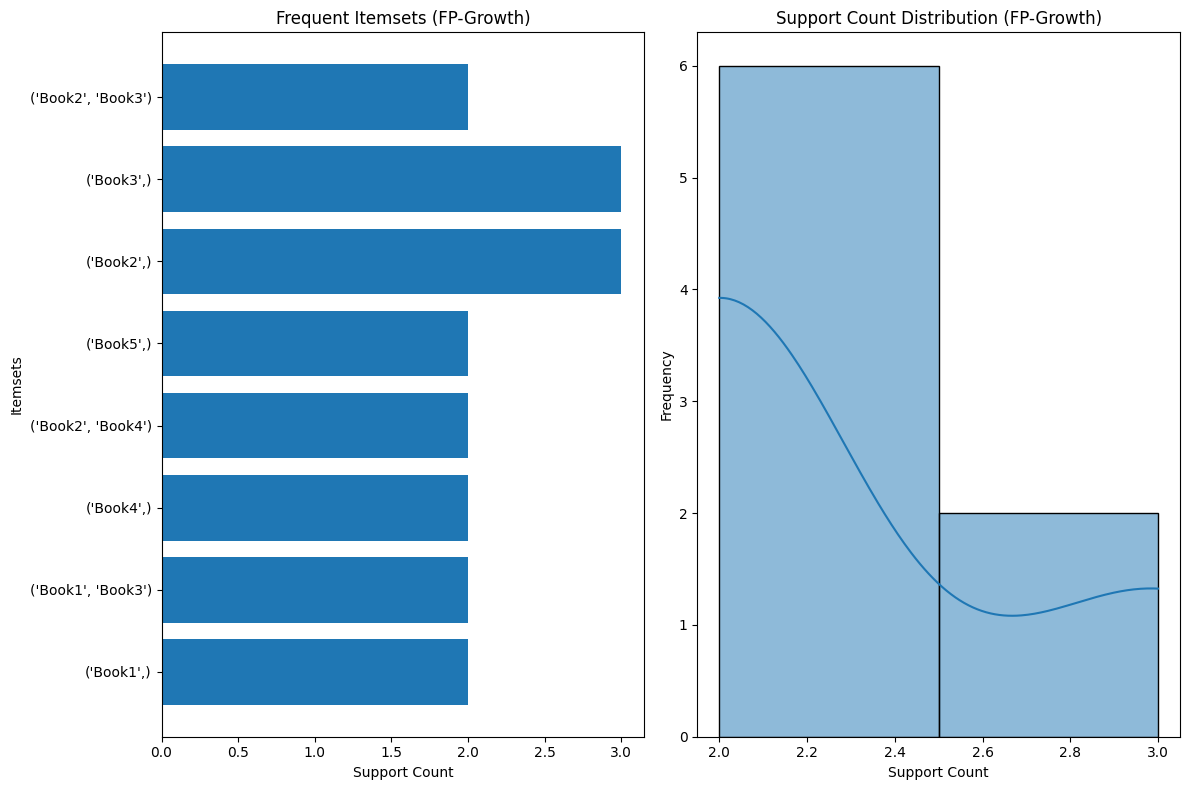

In [1]:
# Install necessary libraries
!pip install pyfpgrowth
import pyfpgrowth
import matplotlib.pyplot as plt
import seaborn as sns

# Sample dataset (replace this with your actual dataset)
buying_books_data= [
    ['Book1', 'Book2', 'Book3'],
    ['Book2', 'Book3', 'Book4'],
    ['Book1', 'Book3', 'Book5'],
    ['Book2', 'Book4', 'Book5']
]

# Convert the dataset to a list of transactions
transactions= [tuple(transaction) for transaction in buying_books_data]

# Apply the FP-growth algorithm
min_support = 2 # Adjust as needed (this is count-based for pyfpgrowth)
patterns = pyfpgrowth.find_frequent_patterns(transactions, min_support)

# Generate association rules
min_confidence = 0.5 # Adjust as needed
rules = pyfpgrowth.generate_association_rules(patterns, min_confidence)

# Display frequent itemsets
print("Frequent Itemsets:")
print(patterns)

# Display association rules
print("\nAssociation Rules:")
print(rules)

# Visualization for FP-Growth Frequent Itemsets
# Convert patterns dictionary to a format suitable for plotting
itemset_labels = [str(itemset) for itemset in patterns.keys()]

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.barh(itemset_labels, list(patterns.values()))
plt.xlabel('Support Count')
plt.ylabel('Itemsets')
plt.title('Frequent Itemsets (FP-Growth)')

plt.subplot(1, 2, 2)
sns.histplot(list(patterns.values()), bins=len(set(patterns.values())), kde=True)
plt.xlabel('Support Count')
plt.ylabel('Frequency')
plt.title('Support Count Distribution (FP-Growth)')

plt.tight_layout()
plt.show()